## Optimization Fundamentals
**Definition** : Finding the best solution from all feasible solutions given certain constraints and objectives.  

**Components of an Optimization Problem :**
* *Decision variables* : what you can control.  
* *Objective function* : what you want to maximize or minimize.  
* *Contraints* : limitations you must respect.
* *Optimal solution :* the best values for decision variables that optimize the objective while satisfying constraints.


## Combinatorial Optimization Problem
**Combinatorial optimization problems** involve finding the best solution from a finite set of discrete solutions.  
It is also finding the optimum (either maximum or minimum) of an objective function whose domain is discrete.

**Examples of combinatorial optimization problems:**  

* **Traveling Salesman Problem (TSP):** Find the shortest route  visiting all cities exactly once.

* **Graph Coloring:** Assign colors to graph nodes such that no adjacent nodes share the same color, using minimum colors

* **Knapsack Problem:** Select items to maximize value without exceeding weight limit.

* **MaxCut Problem:** Partition graph nodes into two sets to maximize edges between sets.

Many real-world problems in industry, science, and daily life can be formulated as general optimization tasks, which are often too large for exhaustive search. Classical approximation algorithms provide near-optimal solutions within a guaranteed ratio, but their computational complexity remains a major challenge for large-scale instances. In recent years, quantum computing has emerged as a promising alternative, with **variational quantum algorithms** for near-term devices attracting significant attention. Among these, the **Quantum Approximate Optimization Algorithm (QAOA)** has become one of the most studied frameworks, offering a general strategy applicable to a wide class of optimization problems. In this work, we focus on analyzing and improving QAOA’s performance, using the **Max-Cut** problem as a benchmark to evaluate its behavior.

## Variational Method
Method for approximiting ground state $\lvert \psi^*\rangle$ and lowest energy $E_{min}$ of quantum system, and it consists of two steps :  
1. Choose ansatz ot trial state paramitrized by $\theta$  
   $$\ket{\psi(\theta)}$$
2. Vary parameters $\theta$ to minimize the energy value
$$E(\theta) = \bra{\psi(\theta)} H \ket{\psi(\theta)}$$

## Variational Quantum Circuit 
A quantum circuit that depends on parameters $\theta_i$  

![](VQC.png)

**VQC** is just a general term for a quantum circuit with parameters optimized classically.  
**QAOA** and **VQE** are instances of **VQCs**.

## Variational Quantum Eigensolvers 
Idea = prepare quantum state with variational quantum circuit $U(\theta)$
$$\ket{\psi(\theta)} = U(\theta)\ket{\psi_0}$$
**VQE** is a general variational algorithm to find the ground state of a Hamiltonian.  
It uses a parametrized quantum circuit and classical optimization.  

![](vqe.png)

## QUBO and Max-Cut
### Quadratic programs
optimization problems with quadratic objective function and linear and quadratic constraints.  
Special case : **Quadratic Unconstrained Binary Optimization (QUBO)**  
**QUBO** is a problem formulation: minimize 

$$ x^T Q x \quad \text{with} \quad x_i \in \{0,1\} $$  
Where $x$ is a vector of binary variables.  
Each $x_i$ represents a decision variable (0 or 1), e.g., in **Max-Cut**, $x_i = $ 0 or 1 depending in which side of the cut node $i$ is assigned to.

So **QUBO** is the problem representation, and it has :
* Quadratic objective function.
* No variable contraints.
* Binary optimization variables.

### Max-Cut problem 
**Graph** is set of verices or nodes V connected by edges.  
1. **Max-Cut (Unweighted)**  
Given an undirected graph $G = (V, E)$ with **vertices** $V$ and **edges** $E$, the **Max-Cut** problem asks you to partition the set of vertices $V$ into two disjoint subsets $S$ and $V/S$ such that the number of edges between the two subsets is maximized.
* Each edge counts as 1 if it connects a vertex in $S$ to a vertex in $S/V$.
* **Goal**: Maximize the total number of “cut edges.”
Example:
Graph with vertices $V = \{1,2,3,4\}$ and edges $E = \{(1, 2),(2, 3),(3, 4),(4, 1)\}$  
Partition $S = \{1,3\}, V/S = \{2,4\}$  
Cut edges: $(1, 2),(2, 3),(3, 4),(4, 1) \rightarrow$ 4 edges cut $\rightarrow$ maximal cut

2. **Max-Cut (Weighted)**
Given an undirected graph $G = (V, E)$ with weights $w_{ij} \ge 0$ on each edge $(i,j)$ the Weighted **Max-Cut** problem asks you to partition the vertices into two subsets $S$ and $V/S$ such that the sum of the weights of edges crossing the partition is maximized.
* Each edge contributes its weight $w_{ij}$ to the cut if its endpoints are in different subsets.
* Goal:  $$\text{maximize} \quad \sum_{(i,j) \in E, i \in S, j \in V \setminus S} w_{ij}$$
Example:
Same graph as before, but edge weights: $w_{12} = 3, w_{23} = 2, w_{34} = 5, w_{41} = 1 $
Partition $S = \{1,3\}, V/S = \{2,4\}$  
Cut edges: $(1, 2)=3, (2, 3)=2, (3, 4)=5, (4, 1)=1 \rightarrow$ Total weight $=11 \rightarrow$ maximal cut.

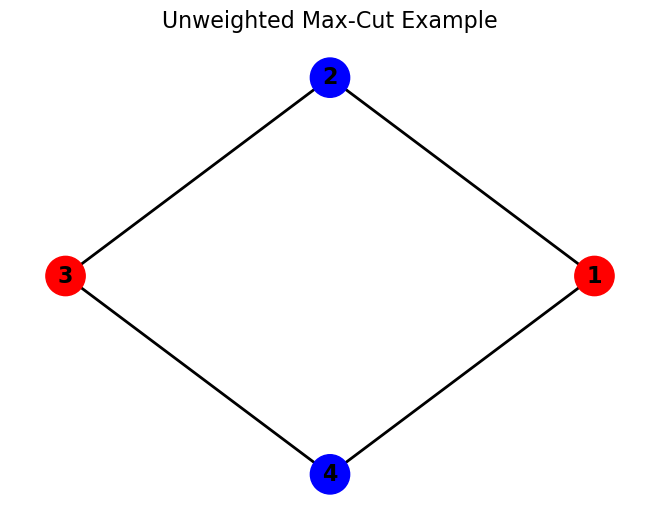

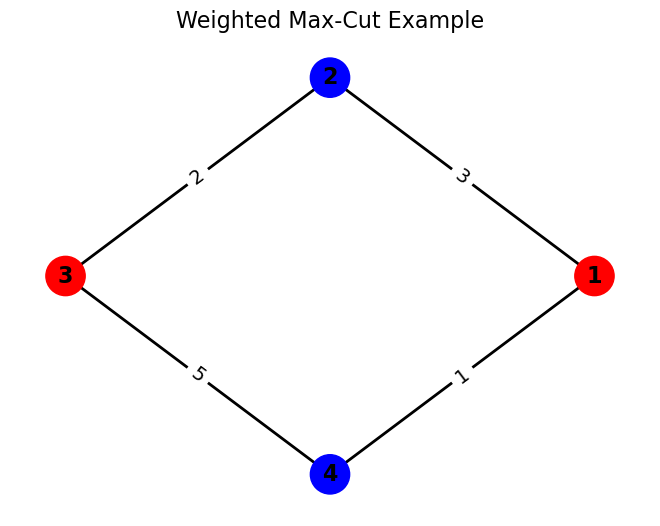

In [101]:
import networkx as nx
import matplotlib.pyplot as plt

# Unweighted graph
G = nx.Graph()
G.add_edges_from([(1,2), (2,3), (3,4), (4,1)])

# Partition: S = {1,3}, V\S = {2,4}
S = {1, 3}
colors = ['red' if node in S else 'blue' for node in G.nodes()]

# Draw the graph
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=800, font_size=16, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=2)
plt.title("Unweighted Max-Cut Example", fontsize=16)
plt.show()


# Weighted graph
G = nx.Graph()
edges = [(1,2,3), (2,3,2), (3,4,5), (4,1,1)]
G.add_weighted_edges_from(edges)

# Partition: S = {1,3}, V\S = {2,4}
S = {1, 3}
colors = ['red' if node in S else 'blue' for node in G.nodes()]

# Draw the graph with edge weights
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=800, font_size=16, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=2)
edge_labels = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=14)
plt.title("Weighted Max-Cut Example", fontsize=16)
plt.show()